<a href="https://colab.research.google.com/github/Raihanbujeee/PCVK_Ganjil_2026/blob/main/modul_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

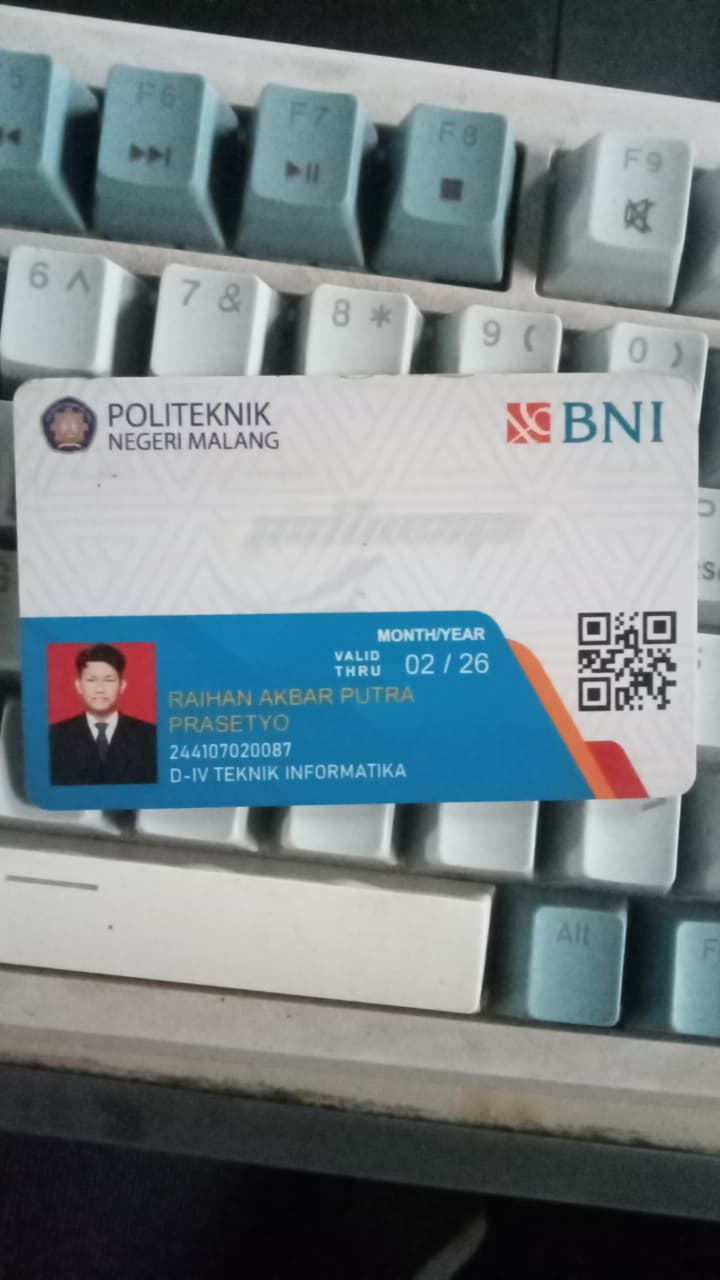

Resolusi gambar:  720  x  1280


In [3]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np

img = cv.imread('/content/drive/MyDrive/PCVK/GAMBAR/ktm.jpeg')
cv2_imshow(img)

print("Resolusi gambar: ", img.shape[1], " x ", img.shape[0])

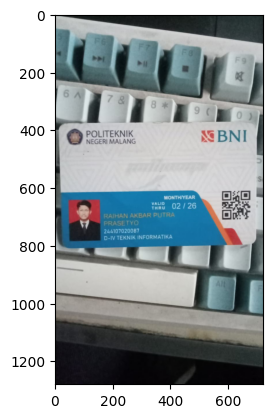

In [4]:
img2 = cv.cvtColor(img, cv.COLOR_BGR2RGB)
plt.imshow(img2)
plt.show()

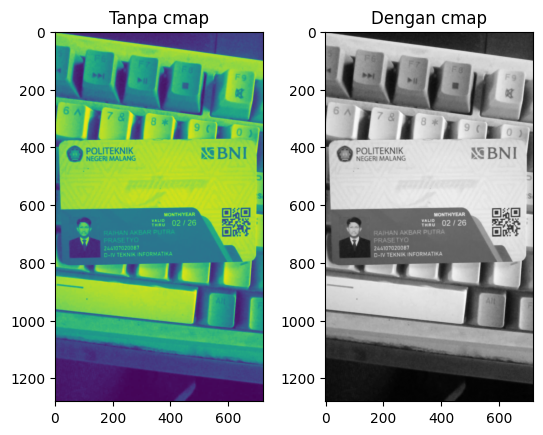

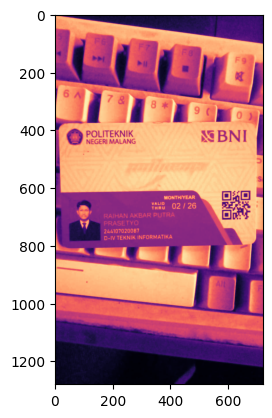

In [6]:

img_gray = cv.imread('/content/drive/MyDrive/PCVK/GAMBAR/ktm.jpeg', cv.IMREAD_GRAYSCALE)

plt.subplot(1, 2, 1)
plt.imshow(img_gray)
plt.title('Tanpa cmap')

plt.subplot(1, 2, 2)
plt.imshow(img_gray, cmap='gray')
plt.title('Dengan cmap')
plt.show()

plt.imshow(img_gray, cmap='magma')
plt.show()

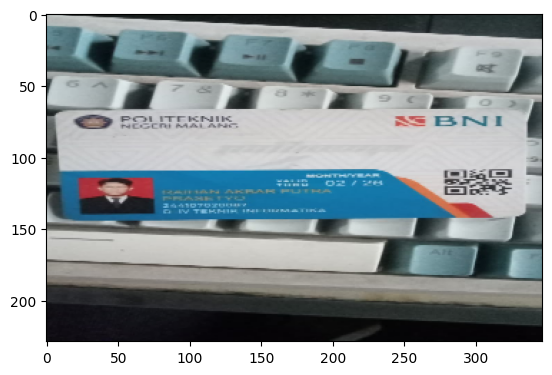

In [8]:
imgRGB = cv.cvtColor(img, cv.COLOR_BGR2RGB) # konversi BGR ke RGB
img_output = cv.resize(imgRGB, (347, 229))
plt.imshow(img_output)
plt.show()

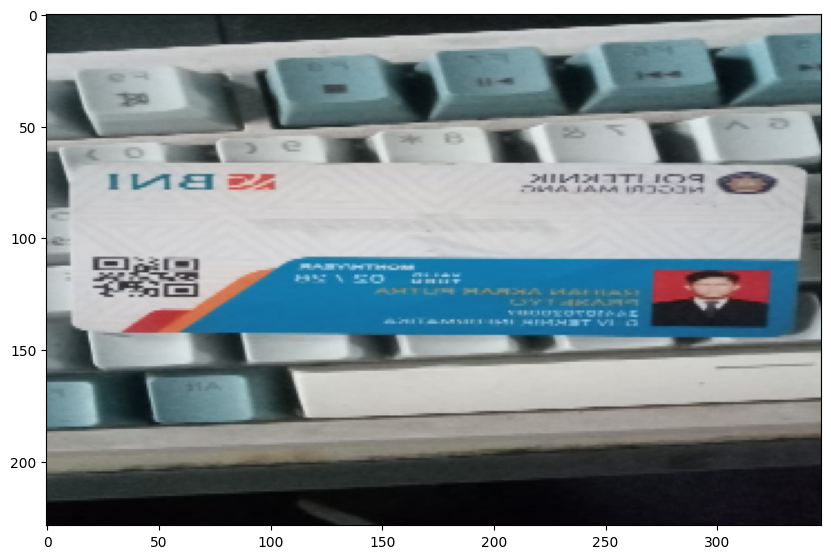

In [10]:
# Balik gambar secara horizontal
imgFlip = cv.flip(img_output, 1)

# Tampilkan ukuran canvas yang lebih besar
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1, 1, 1)
ax.imshow(imgFlip)
plt.show()

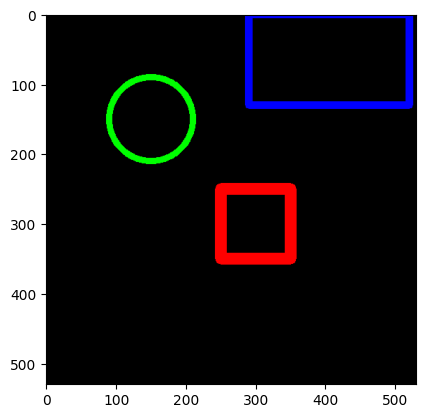

In [19]:
# A. Bikin black image ukuran 530x530
black_img = np.zeros(shape=(530, 530, 3), dtype=np.int16)

# B. Bikin kotak Biru di kanan atas
cv.rectangle(black_img, pt1=(290, 0), pt2=(520, 130), color=(0, 0, 255), thickness=10)

# C. Bikin kotak Merah di tengah
cv.rectangle(black_img, pt1=(250, 250), pt2=(350, 350), color=(255, 0, 0), thickness=15)

# D. Bikin lingkaran Hijau di kiri tengah
cv.circle(black_img, center=(150, 150), radius=60, color=(0, 255, 0), thickness=8)

# Tampilkan hasil akhirnya
plt.imshow(black_img)
plt.show()

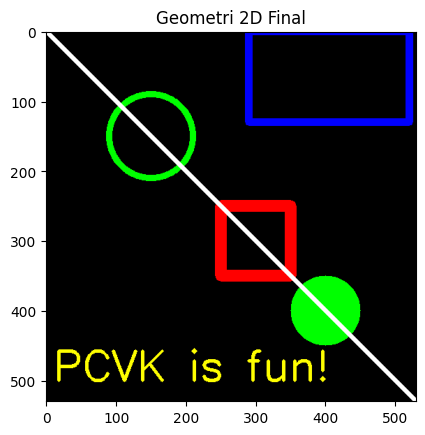

In [21]:
# Tambahan Lingkaran Hijau (nge-blok/full karena thickness=-1)
cv.circle(black_img, center=(400, 400), radius=50, color=(0, 255, 0), thickness=-1)

# Tambahan Garis Putih Menyilang dari ujung ke ujung
cv.line(black_img, pt1=(0, 0), pt2=(530, 530), color=(255, 255, 255), thickness=5)

# Tambahan Teks "PCVK is fun!" warna kuning
font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(black_img, text='PCVK is fun!', org=(10, 500), fontFace=font, fontScale=2, color=(255, 255, 0), thickness=3, lineType=cv.LINE_AA)

# Tampilkan gambar finalnya!
plt.imshow(black_img)
plt.title("Geometri 2D Final")
plt.show()

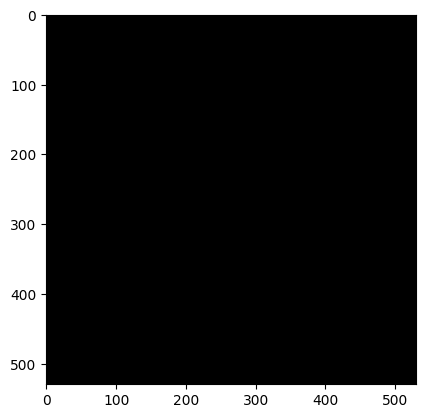

In [22]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

# Pembuatan black image kembali dilakukan dengan tipe data int32
black_img2 = np.zeros(shape=(530, 530, 3), dtype=np.int32)
plt.imshow(black_img2)

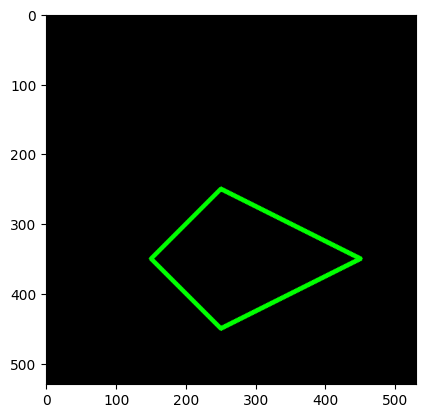

In [23]:
# Inisialisasi NumPy array dengan titik-titik sudut
vertices = np.array([[150, 350], [250, 250], [450, 350], [250, 450]], dtype=np.int32)

# Array tersebut kemudian di-reshape
pts = vertices.reshape((-1, 1, 2))

# Penambahan polyline pada black image kedua yang telah dibuat
# color=(0, 255, 0) itu kode buat warna Hijau ya bro
cv.polylines(black_img2, [pts], isClosed=True, color=(0, 255, 0), thickness=5)

plt.imshow(black_img2)
plt.show()

PERTANYAAN PRAKTIKUM

jawaban nomer 1: Perbedaan cv2_imshow dan plt.imshow
Beda karena OpenCV membaca citra secara default dalam format BGR, sedangkan Matplotlib menganggapnya RGB. Jika langsung pakai Matplotlib tanpa konversi, channel warna Merah dan Biru akan tertukar. Buktinya, nilai piksel pada matriks aslinya tetap sama, hanya cara library menerjemahkan urutan warnanya saja yang berbeda.

Tampilan cv2_imshow (BGR):


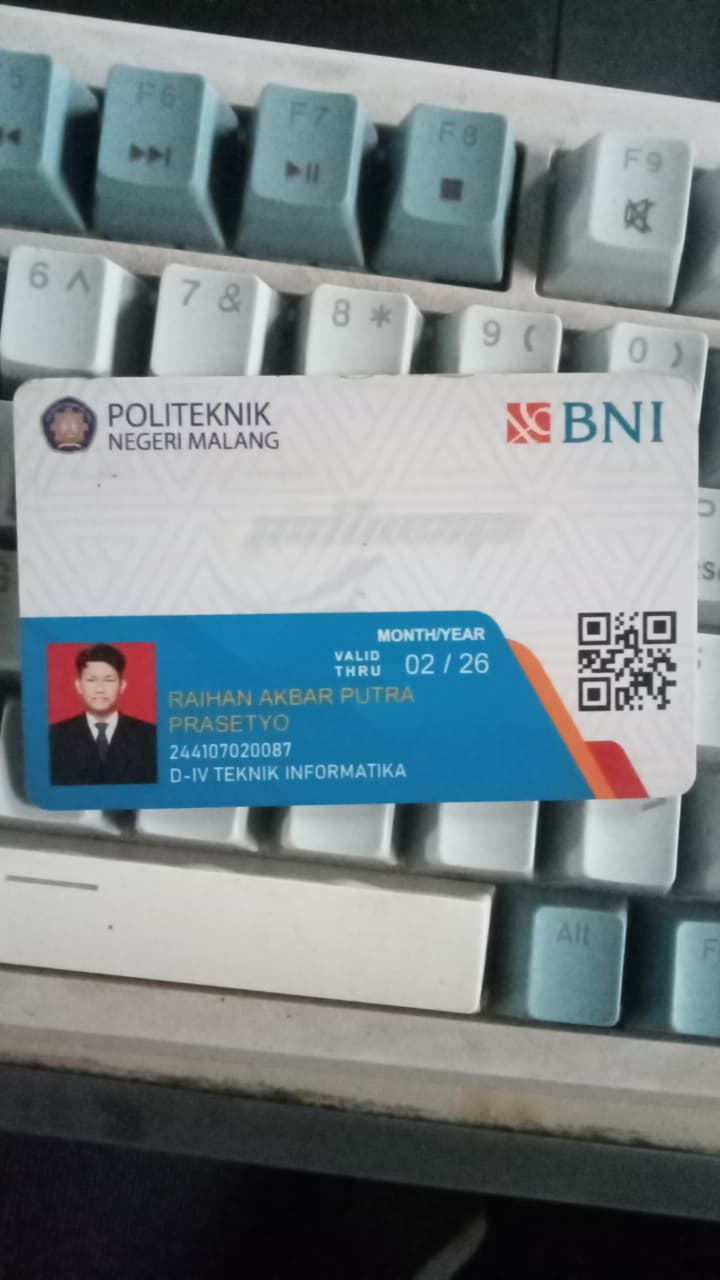

Tampilan plt.imshow (RGB):


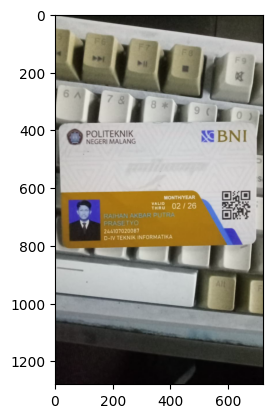

Nilai pixel di posisi [0,0] dari cv2.imread: [33 35 29]


In [24]:
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow


img = cv2.imread('/content/drive/MyDrive/PCVK/GAMBAR/ktm.jpeg')

print("Tampilan cv2_imshow (BGR):")
cv2_imshow(img)

# Tampilkan dengan plt.imshow (Warna Tertukar)
print("Tampilan plt.imshow (RGB):")
plt.imshow(img)
plt.show()

# Bukti nilai pixel
print("Nilai pixel di posisi [0,0] dari cv2.imread:", img[0,0])


Jawaban nomer 2: Perbandingan int16 dan int32
Secara tampilan tidak ada bedanya (sama-sama hitam pekat). Namun, ukuran memori sangat berbeda. int32 memakan kapasitas memori (nbytes) tepat dua kali lipat lebih besar dibanding int16 karena ia mengalokasikan 32-bit data per pikselnya, bukan 16-bit.

In [25]:
import numpy as np

img16 = np.zeros((100, 100, 3), dtype=np.int16)
img32 = np.zeros((100, 100, 3), dtype=np.int32)

print("Canvas int16:")
print("- dtype:", img16.dtype)
print("- min():", img16.min())
print("- max():", img16.max())
print("- nbytes:", img16.nbytes, "bytes\n")

print("Canvas int32:")
print("- dtype:", img32.dtype)
print("- min():", img32.min())
print("- max():", img32.max())
print("- nbytes:", img32.nbytes, "bytes")

Canvas int16:
- dtype: int16
- min(): 0
- max(): 0
- nbytes: 60000 bytes

Canvas int32:
- dtype: int32
- min(): 0
- max(): 0
- nbytes: 120000 bytes


Jawaban nomer 3: Fungsi cv2.imshow() bawaan OpenCV didesain untuk membuka jendela aplikasi baru (pop-up GUI) di sistem operasi komputer lokal. Karena Google Colab berjalan di atas server cloud secara headless (tanpa monitor) dan diakses melalui web browser, fungsi tersebut akan menyebabkan program crash atau error. Oleh karena itu, Google membuat patch khusus yaitu from google.colab.patches import cv2_imshow agar citra dapat di-render dan ditampilkan secara inline langsung di dalam halaman notebook Colab.

Jawaban nomer 4: Keduanya menampilkan warna sebenarnya dan tidak ada kanal yang tertukar. skimage secara bawaan membaca citra langsung dalam format RGB. Sedangkan citra OpenCV yang awalnya BGR telah dikonversi paksa ke RGB. Buktinya, jika nilai matriks piksel keduanya dicetak, hasilnya 100% identik.

In [26]:
import cv2
from skimage import io

path = '/content/drive/MyDrive/PCVK/GAMBAR/ktm.jpeg'

img_skimage = io.imread(path)

img_cv2 = cv2.imread(path)
img_cv2_rgb = cv2.cvtColor(img_cv2, cv2.COLOR_BGR2RGB)

print("Nilai pixel [0,0] Skimage     :", img_skimage[0,0])
print("Nilai pixel [0,0] OpenCV (RGB):", img_cv2_rgb[0,0])


Nilai pixel [0,0] Skimage     : [29 35 33]
Nilai pixel [0,0] OpenCV (RGB): [29 35 33]


Jawaban nomer 5: Efek figsize pada img.shape
Nilai img.shape tidak berubah. Perbedaannya: mengubah figsize hanya sekadar memperbesar ukuran bingkai tampilan visual di layar (seperti di-zoom), sedangkan mengubah ukuran citra (cv2.resize) benar-benar merombak struktur jumlah piksel pada matriks datanya.

PRAKTIKUM PENERAPAN

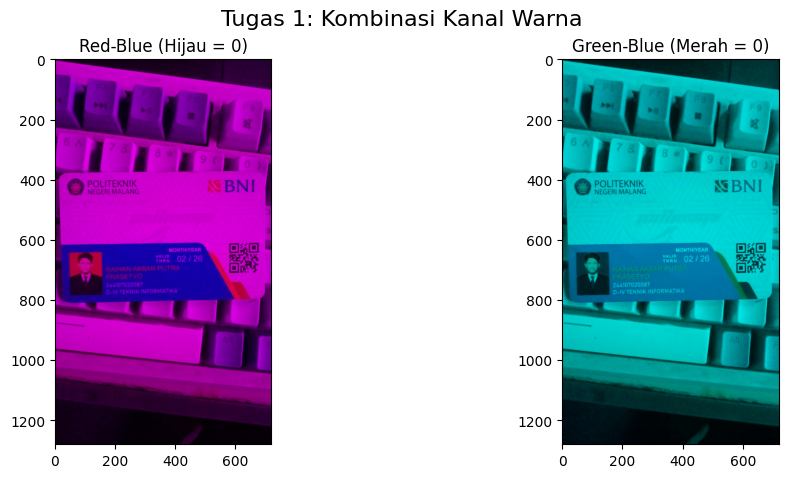

In [27]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('/content/drive/MyDrive/PCVK/GAMBAR/ktm.jpeg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# A. Kombinasi Red-Blue (Hijau/index 1 dinolkan)
img_rb = img_rgb.copy()
img_rb[:, :, 1] = 0

# B. Kombinasi Green-Blue (Merah/index 0 dinolkan)
img_gb = img_rgb.copy()
img_gb[:, :, 0] = 0

# Tampilkan berdampingan
plt.figure(figsize=(12, 5))
plt.suptitle("Tugas 1: Kombinasi Kanal Warna", fontsize=16)

plt.subplot(1, 2, 1)
plt.imshow(img_rb)
plt.title("Red-Blue (Hijau = 0)")

plt.subplot(1, 2, 2)
plt.imshow(img_gb)
plt.title("Green-Blue (Merah = 0)")

plt.show()

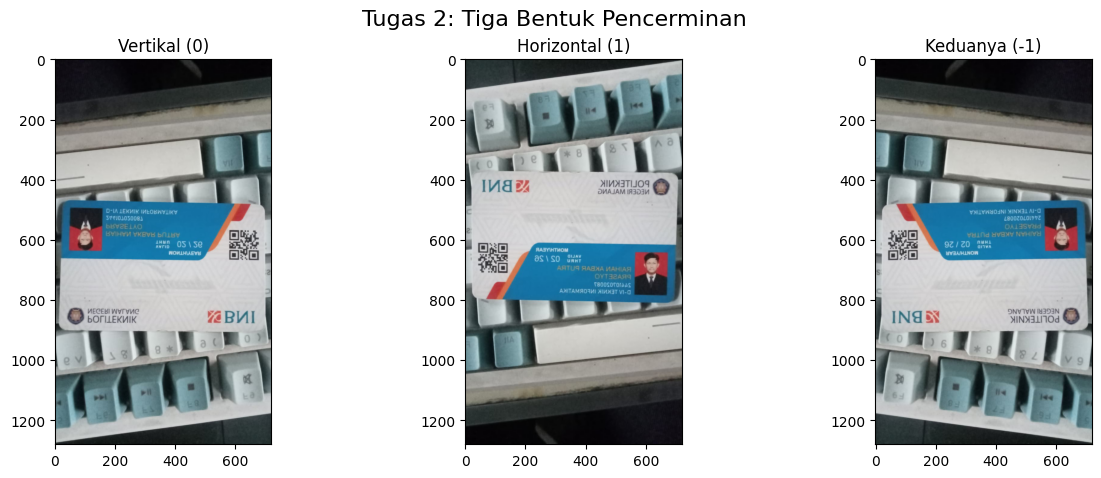

In [28]:
# Proses Flipping
img_vertikal = cv2.flip(img_rgb, 0)
img_horizontal = cv2.flip(img_rgb, 1)
img_keduanya = cv2.flip(img_rgb, -1)

# Tampilkan 3 gambar sejajar
plt.figure(figsize=(15, 5))
plt.suptitle("Tugas 2: Tiga Bentuk Pencerminan", fontsize=16)

plt.subplot(1, 3, 1)
plt.imshow(img_vertikal)
plt.title("Vertikal (0)")

plt.subplot(1, 3, 2)
plt.imshow(img_horizontal)
plt.title("Horizontal (1)")

plt.subplot(1, 3, 3)
plt.imshow(img_keduanya)
plt.title("Keduanya (-1)")

plt.show()

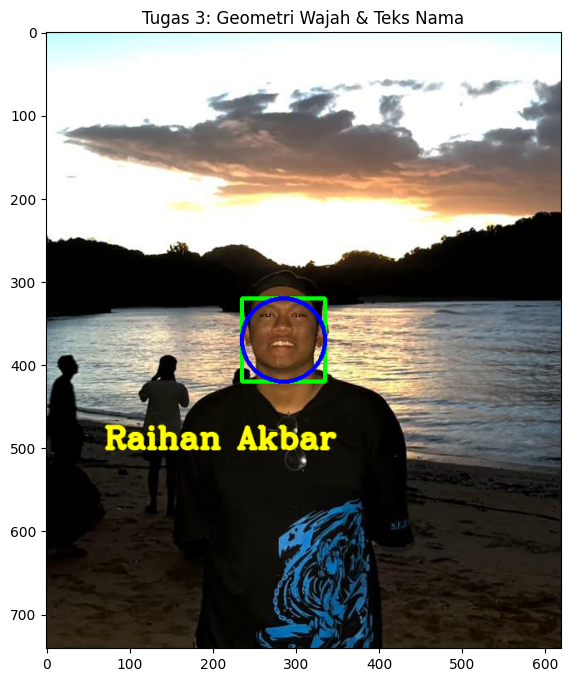

In [30]:

foto_aktivitas = cv2.imread("/content/drive/MyDrive/PCVK/GAMBAR/Raihan.jpeg")
foto_rgb = cv2.cvtColor(foto_aktivitas, cv2.COLOR_BGR2RGB)


cv2.rectangle(foto_rgb, pt1=(235, 320), pt2=(335, 420), color=(0, 255, 0), thickness=3)
cv2.circle(foto_rgb, center=(285, 370), radius=50, color=(0, 0, 255), thickness=3)

font = cv2.FONT_HERSHEY_COMPLEX

cv2.putText(foto_rgb, text="Raihan Akbar", org=(70, 500), fontFace=font, fontScale=1.2, color=(255, 255, 0), thickness=3, lineType=cv2.LINE_AA)

plt.figure(figsize=(10, 8))
plt.imshow(foto_rgb)
plt.title("Tugas 3: Geometri Wajah & Teks Nama")
plt.show()

PRAKTIKUM ANALISA

1. Pertanyaan
Berapa persentase piksel pada citra KTM (dalam mode Grayscale) yang memiliki nilai intensitas sangat terang (nilai piksel di atas 200), dan apakah area terang ini mendominasi keseluruhan gambar?

2. Rancangan Program
Untuk menjawab pertanyaan di atas, rancangan programnya adalah:

Membaca file citra ktm.jpeg menggunakan OpenCV langsung dalam format Grayscale (cv.IMREAD_GRAYSCALE).

Menghitung total keseluruhan piksel pada citra menggunakan atribut .size dari NumPy array.

Mencari dan menghitung jumlah piksel yang memiliki nilai intensitas lebih besar dari 200 menggunakan operasi kondisi NumPy (np.sum(img > 200)).

Menghitung persentasenya dengan rumus: (Jumlah Piksel Terang / Total Piksel) * 100.

Menampilkan data hasil perhitungannya menggunakan print.

In [31]:
import cv2 as cv
import numpy as np

# 1. Baca citra KTM grayscale
img_gray = cv.imread('/content/drive/MyDrive/PCVK/GAMBAR/ktm.jpeg', cv.IMREAD_GRAYSCALE)

# 2. Hitung total piksel
total_pixel = img_gray.size

# 3. Hitung piksel yang nilainya > 200 (terang/hampir putih)
piksel_terang = np.sum(img_gray > 200)

# 4. Hitung persentase
persentase = (piksel_terang / total_pixel) * 100

# 5. Tampilkan hasil
print(f"Total keseluruhan piksel : {total_pixel}")
print(f"Jumlah piksel terang (>200) : {piksel_terang}")
print(f"Persentase piksel terang : {persentase:.2f}%")

Total keseluruhan piksel : 921600
Jumlah piksel terang (>200) : 196172
Persentase piksel terang : 21.29%


3. Data Hasil

Total keseluruhan piksel : 921600
Jumlah piksel terang (>200) : 196172
Persentase piksel terang : 21.29%

4. Kesimpulan
Berdasarkan data hasil di atas, dapat disimpulkan bahwa piksel dengan intensitas sangat terang (>200) menyumbang sebesar 21.29% dari total keseluruhan citra KTM. Hal ini membuktikan dan selaras dengan pengamatan visual bahwa citra KTM didominasi oleh area latar belakang (background) yang berwarna cerah/putih, sedangkan area gelap (seperti teks identitas, barcode, dan foto wajah/jas) hanya menempati porsi yang lebih kecil dari keseluruhan dimensi citra.

**PRAKTIKUM** **APLIKASI**

studi kasus 1


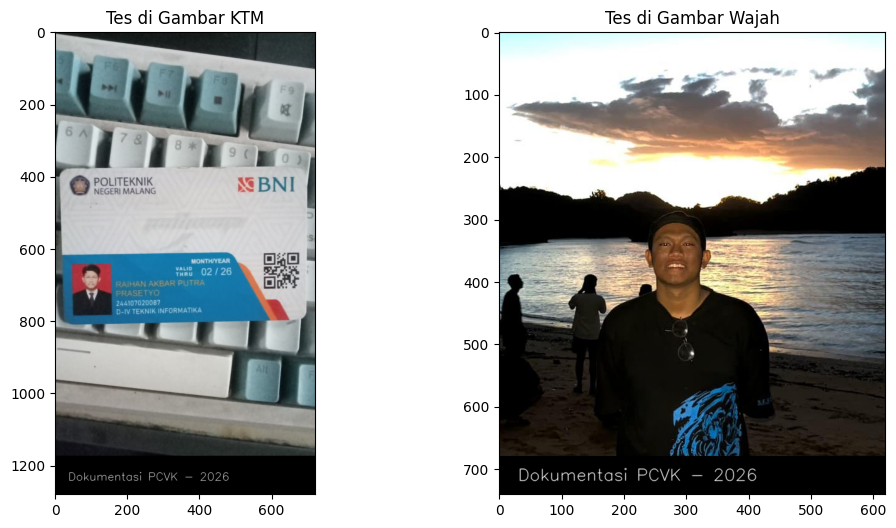

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def tambah_label_adaptif(image_path):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w = img_rgb.shape[:2]


    bar_h = h // 12

    cv2.rectangle(img_rgb, pt1=(0, h - bar_h), pt2=(w, h), color=(0, 0, 0), thickness=-1)

    skala_font = w / 700.0
    tebal_huruf = max(1, int(skala_font * 1.8))

    x_teks = int(w * 0.05)
    y_teks = int(h - (bar_h * 0.35))
    cv2.putText(img_rgb, "Dokumentasi PCVK - 2026", org=(x_teks, y_teks),
                fontFace=cv2.FONT_HERSHEY_SIMPLEX, fontScale=skala_font,
                color=(255, 255, 255), thickness=tebal_huruf, lineType=cv2.LINE_AA)

    return img_rgb

img_hasil_1 = tambah_label_adaptif("/content/drive/MyDrive/PCVK/GAMBAR/ktm.jpeg")
img_hasil_2 = tambah_label_adaptif("/content/drive/MyDrive/PCVK/GAMBAR/Raihan.jpeg")

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(img_hasil_1); plt.title("Tes di Gambar KTM")
plt.subplot(1, 2, 2); plt.imshow(img_hasil_2); plt.title("Tes di Gambar Wajah")
plt.show()

STUDI KASUS 2

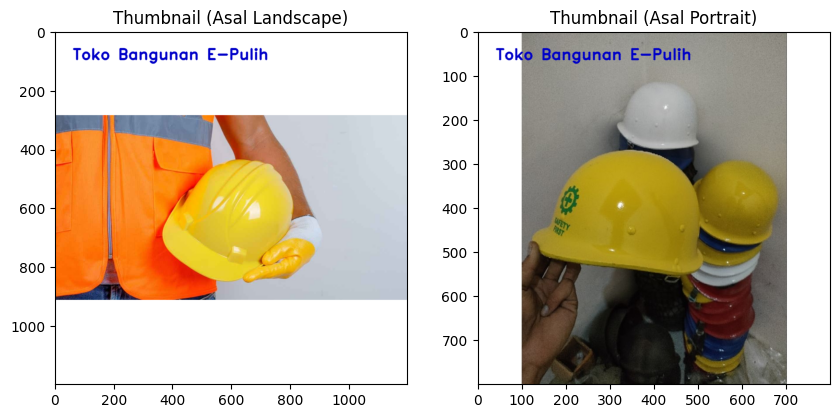

In [37]:
def bikin_thumbnail_olshop(image_path, nama_toko):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w = img_rgb.shape[:2]

    sisi_persegi = max(h, w)

    canvas = np.ones((sisi_persegi, sisi_persegi, 3), dtype=np.uint8) * 255

    y_offset = (sisi_persegi - h) // 2
    x_offset = (sisi_persegi - w) // 2

    canvas[y_offset : y_offset + h, x_offset : x_offset + w] = img_rgb

    skala_font = sisi_persegi / 700.0
    tebal_huruf = max(1, int(skala_font * 2))

    cv2.putText(canvas, nama_toko, org=(int(sisi_persegi * 0.05), int(sisi_persegi * 0.08)),
                fontFace=cv2.FONT_HERSHEY_DUPLEX, fontScale=skala_font,
                color=(0, 0, 200), thickness=tebal_huruf, lineType=cv2.LINE_AA)

    return canvas
thumb_1 = bikin_thumbnail_olshop("/content/drive/MyDrive/PCVK/GAMBAR/Helm.jpg", "Toko Bangunan E-Pulih")
thumb_2 = bikin_thumbnail_olshop("/content/drive/MyDrive/PCVK/GAMBAR/helm_2.jpg", "Toko Bangunan E-Pulih")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(thumb_1); plt.title("Thumbnail (Asal Landscape)")
plt.subplot(1, 2, 2); plt.imshow(thumb_2); plt.title("Thumbnail (Asal Portrait)")
plt.show()